<center><img src="https://i.imgur.com/YNtjmbq.png" width="800"></center> 


# EXPLORACION DE REDES Y SUS NODOS


<div class="alert alert-info" role="alert">
    
**Data para la sesión**

Para esta sesión, los datos puedes descargarlos en _tu_ carpeta **data** desde este [enlace](https://drive.google.com/drive/folders/1xri-lWtXZv-7Ce5_xJ31GQFVnJZJ1zeo?usp=sharing).
</div>



En el año 2018, Quinten Dol sugirió a los usuarios de Twitter seguir a estas celebridades de la Tecnologia local:


<a href="https://www.builtinseattle.com/articles/50-seattle-tech-twitter-accounts-to-follow" target="_blank">
    <img src="https://github.com/maestriaInnovacion-magallanes-redes/exploracion/raw/main/picsForSession/influentialTweet.jpg
" alt="Influential Tweet" style="max-width: 100%; height: auto;">
</a>

Aunque proponía 50 _influencers_, sólo hay 46 activos en X (antes Twitter). Se construyó una red para ver si entre ellos se seguían, y [esto tenemos](https://docs.google.com/spreadsheets/u/1/d/e/2PACX-1vQaaNQb2frjnlt0fPSBQhp5tNydB0a9ibp98sblBn6OfvGd8vsx8cfHb4w8Cm_qC3EIeYFby_zNQBoK/pubhtml):

In [1]:
from IPython.display import IFrame
IFrame('https://docs.google.com/spreadsheets/d/e/2PACX-1vQvzPtFqK2pgq8xGLZy4EsGyT0RU-3ghuqhJOmEm8J0YEZ1SOjXn1aLGZmKIUmTGRr-ww1jdULhAPvz/pubhtml', 800, 350)

## Creando la red

Como ya sabemos, la red se arma con la **adjacency matrix** o la **edgelist**. Hagámoslo nuevamente:

In [2]:
# librerias necesarias
import networkx as nx
import pandas as pd

# link a GoogleDrive como un Excel
linkGoogle="https://docs.google.com/spreadsheets/d/e/2PACX-1vQvzPtFqK2pgq8xGLZy4EsGyT0RU-3ghuqhJOmEm8J0YEZ1SOjXn1aLGZmKIUmTGRr-ww1jdULhAPvz/pub?output=xlsx"

# leyendo archivo de red
adjacency=pd.read_excel(linkGoogle,   
                        index_col=0,  # la columna '0' guarda los nombres
                        sheet_name='adjacency') # la tabla tiene este nombre



Los grafos de las tredes sociales como `Twitter` / `X` son generalmente **dirigidos** pues un nodo sigue a otro, pero la relación no es necesariamente recíproca. 

In [3]:
# creando red dirigida
TopFromAdjacency=nx.from_pandas_adjacency(adjacency,create_using=nx.DiGraph)
# info de lo que tenemos
print(TopFromAdjacency)

DiGraph with 46 nodes and 588 edges


El objeto **TopFromAdjacency** contiene a la `red dirigida`.

¿Tendremos algun _influencer_ que no siga a otro ni sea seguido por otro?

In [4]:
list(nx.isolates(TopFromAdjacency))

[]

De ahi que la red no mostrará nodos aislados:

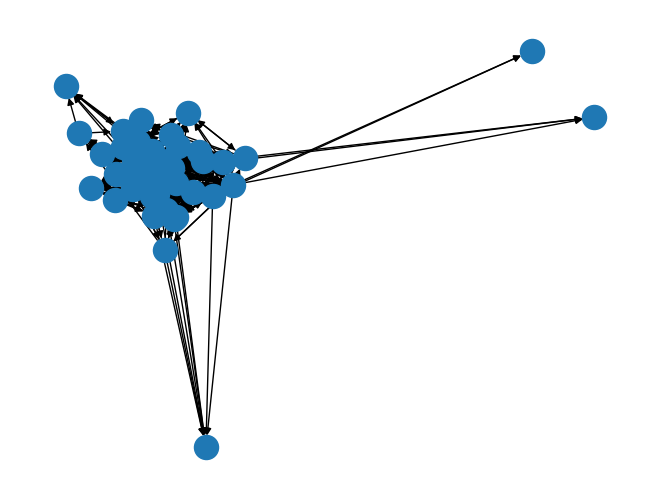

In [5]:
nx.draw(TopFromAdjacency)

## Añadiendo atributos

Notese que tenemos atributos para la red:

In [6]:
atributos=pd.read_excel(linkGoogle,   
                        index_col=0,  # la columna '0' guarda los nombres
                        sheet_name='attributes') # la tabla tiene este nombre

# nota que la columna 1 la abrí como el nombre de fila (index)
atributos.head(20)

,male,followers
Id,,
rachelerman,0,7139
mattmcilwain,1,2804
DaveParkerSEA,1,3328
toddbishop,1,24500
ashannstew,0,3382
LeslieFeinzaig,0,15900
akipman,1,29500
matt_oppy,1,4847
gilbert,1,25800


Los atributos de cada nodo deben ser parte de la red dirigida actual. El proceso es simple:

In [7]:
# Convertimos el DataFrame en un diccionario indexado por el nodo
atributos_nodos = atributos.to_dict('index')

# Pasamos todos los atributos al grafo de un solo golpe
nx.set_node_attributes(TopFromAdjacency, atributos_nodos)

Podemos verificarlo asi:

In [8]:
TopFromAdjacency.nodes(data=True)

NodeDataView({'rachelerman': {'male': 0, 'followers': 7139}, 'mattmcilwain': {'male': 1, 'followers': 2804}, 'DaveParkerSEA': {'male': 1, 'followers': 3328}, 'toddbishop': {'male': 1, 'followers': 24500}, 'ashannstew': {'male': 0, 'followers': 3382}, 'LeslieFeinzaig': {'male': 0, 'followers': 15900}, 'akipman': {'male': 1, 'followers': 29500}, 'matt_oppy': {'male': 1, 'followers': 4847}, 'gilbert': {'male': 1, 'followers': 25800}, 'juliesandler': {'male': 0, 'followers': 7031}, 'BradSmi': {'male': 1, 'followers': 96300}, 'crashdev': {'male': 0, 'followers': 8773}, 'ShaunaCausey': {'male': 0, 'followers': 47400}, 'john_gabbert': {'male': 1, 'followers': 2482}, 'moniguzman': {'male': 0, 'followers': 29000}, 'mattmday': {'male': 1, 'followers': 5750}, 'Rich_Barton': {'male': 1, 'followers': 31300}, 'daryn': {'male': 1, 'followers': 2378}, 'lovelletters': {'male': 0, 'followers': 4553}, 'etzioni': {'male': 1, 'followers': 27400}, 'MissDestructo': {'male': 0, 'followers': 41800}, 'heatherre

Ya con esto, podemos exportarlo:

In [9]:
filename1='seattle.gml' # nombre incluye 'donde'
filename2='seattle.graphml'

# guardando:
nx.write_gml(TopFromAdjacency,filename1)

nx.write_graphml(TopFromAdjacency,filename2)

<div class="alert alert-warning" role="alert">
    
#### En Gephi  
    
**Usa GEPHI y abre la red de los tech influencers de Seattle.**

</div>

Gephi abre los archivos `gml` o `graphml` directamente. Pero si no quieres pasar por Python y usar el Excel directamente, requiere dos pasos:
1. Importar la matriz desde excel (visto enla primera sesión)
2. Importar y combinar los atributos desde Excel.

 El segundo paso lo detallo a continuación:

La importación usa la misma opción del menú: `importar hoja de calculo` (como lo usaste con la matriz), pero esta vez hay otras opciones a elegir:

<img src="https://github.com/maestriaInnovacion-magallanes-redes/exploracion/raw/main/picsForSession/importAttr1.jpg" width="500"/>


En el siguiente paso, elije el tipo respectivo de datos para cada columna, por ejemplo:

<img src="https://github.com/maestriaInnovacion-magallanes-redes/exploracion/raw/main/picsForSession/importAttr2.jpg" width="500"/>


Por lo general, podemos explorar la red de dos maneras:

1. A nivel de red en total.
2. A nivel de cada actor (nodo).

> Como la sesión anterior, trabajaremos en paralelo Python (networkx) y **Gephi**. Para Gephi nos enfocaremos en los comandos mostrados a continación:


<img src="https://github.com/maestriaInnovacion-magallanes-redes/exploracion/raw/main/picsForSession/menuStatsGephi.jpg"/>



# 1. Explorando a nivel de red

A continuación, se detallan las métricas fundamentales para comprender la red como una entidad completa.

| Indicador Global    | Tipo                    | ¿Sensible a Dirección? | Rango Teórico | Interpretación                                                                                                       |
| ------------------- | ----------------------- | ---------------------- | ------------- | -------------------------------------------------------------------------------------------------------------------- |
| **Conectividad**    | Integración estructural | Sí                     | Cualitativo   | Evalúa si la red forma una estructura integrada o fragmentada, considerando la existencia de caminos entre nodos.    |
| **Diámetro**        | Distancia               | Sí                     | (1) a (N-1)   | Máxima distancia geodésica observada entre pares de nodos alcanzables. Representa el peor escenario de comunicación. |
| **Distancia Media** | Distancia               | Sí                     | (1) a (N-1)   | Número promedio de pasos requeridos para conectar pares de nodos alcanzables.                                        |
| **Densidad**        | Cohesión                | Sí                     | 0% a 100%     | Proporción de enlaces observados respecto del total de enlaces posibles.                                             |
| **Alcanzabilidad**  | Integración estructural | Sí                     | 0% a 100%     | Proporción de pares de nodos para los cuales existe al menos un camino dirigido.                                     |
| **Reciprocidad**    | Mutualidad              | Exclusivo de dirigidos | 0% a 100%     | Proporción de relaciones bidireccionales respecto del total de vínculos dirigidos.                                   |


## Conectividad

Una de las primeras interrogantes, es saber si cada nodo puede conectarse con otro nodo. Para que ello sucede, teniendo en cuenta que la red es dirigida, debe haber un **path** o camino (sequencia de flechas) entre todo par de nodos de la red. Si esto fuera así, se debe verificar que la red es **strongly_connected**.

En la Figura 1 vemos una red que tiene componentes fuertemente conectados, pero la red en su totalidad no lo es:
<figure>
<img src="https://github.com/MAGALLANESJoseManuel/MGPIT_Pol748_Redes_2/raw/main/picsForSession/strongly_connected.png" style="width:70%">
<figcaption align = "center"> Figura 1. Red y componentes fuertemente conectados </figcaption>
    <a href="https://en.wikipedia.org/wiki/Strongly_connected_component" class="alert-link">Fuente:Wikipedia</a>
</figure>


Nuestra red tampoco lo es:

In [10]:
nx.is_strongly_connected(TopFromAdjacency)

False

Veamos cuántos hay de cada uno:

In [11]:
# 1. Calcular la cantidad de componentes fuertemente conectados
# (Nodos que pueden ir y venir entre sí siguiendo la dirección de las flechas)
num_strong_components = nx.number_strongly_connected_components(TopFromAdjacency)

# 2. Calcular la cantidad de componentes débilmente conectados
# (Nodos conectados si ignoramos temporalmente la dirección de las flechas)
num_weak_components = nx.number_weakly_connected_components(TopFromAdjacency)

# Desplegar los resultados de forma ejecutiva
print(f"Componentes Fuertemente Conectados (Strong): {num_strong_components}")
print(f"Componentes Débilmente Conectados (Weak): {num_weak_components}")

Componentes Fuertemente Conectados (Strong): 4
Componentes Débilmente Conectados (Weak): 1


<div class="alert alert-warning" role="alert">
    
#### En Gephi  
    
Utilizar la opción **Connected Components**

</div>

## Distancia y Geodésicos

La **distancia** entre dos nodos se entiende como la cantidad de enlaces (*edges*) necesarios para ir de un nodo a otro dentro de la red.

Como entre dos nodos pueden existir múltiples caminos posibles, llamamos **geodésico** al camino más corto entre ellos; es decir, a la menor distancia observable entre ambos nodos. La Figura 2 muestra algunos ejemplos de geodésicos.

<figure>
<img src="https://github.com/MAGALLANESJoseManuel/MGPIT_Pol748_Redes_2/raw/main/picsForSession/geodesics.png" style="width:70%">
<figcaption align = "center"> Figura 2. Geodésicos. 
 </figcaption>
 <a href="https://www.wolframphysics.org/technical-introduction/limiting-behavior-and-emergent-geometry/geodesics/" class="alert-link">Fuente: Wolframphysics</a>
</figure>

A partir de las distancias geodésicas podemos construir varias métricas globales de estructura, entre ellas el **diámetro** y la **distancia media** de la red.



### a. Diámetro

Una métrica clave  que podemos calcular de la matriz de geodésicos es el **diámetro**. El diámetro es el máximo de los geodésico, pues representa la distancia mas corta entre las celdas mas alejadas de la red. Veámoslo en la Figura 3.

<figure>
<img src="https://github.com/MAGALLANESJoseManuel/MGPIT_Pol748_Redes_2/raw/main/picsForSession/diameter.png" style="width:70%">
<figcaption align = "center"> Figura 3. Diámetro. 
 </figcaption>
 Fuente: Autor.
</figure>


La función **diameter()** no podemos calcularlo de una red que no se fuertemente conectada. Pero tratemos dos opciones informativas:

<div class="alert alert-success" role="alert">

#### Nota Técnica: Excentricidad, Radio y Diámetro

Las distancias geodésicas también permiten identificar qué tan “lejos” se encuentra cada nodo respecto del resto de la red.

La **excentricidad** de un nodo representa la mayor distancia geodésica entre ese nodo y cualquier otro nodo alcanzable de la red. En otras palabras, mide el peor escenario de distancia para un nodo dado.

Un nodo con baja excentricidad se encuentra relativamente cerca del resto de actores de la red, mientras que uno con alta excentricidad ocupa posiciones más periféricas.

A partir de las excentricidades se derivan dos métricas globales:

* el **radio**, que corresponde a la menor excentricidad observada en la red;
* y el **diámetro**, que corresponde a la mayor excentricidad observada.

Así, el radio identifica el nodo más central según su peor distancia posible, mientras que el diámetro representa la separación máxima observada dentro de la red.

</div>

In [12]:
TopFromAdjacency_ND=TopFromAdjacency.to_undirected()
nx.eccentricity(TopFromAdjacency_ND)
sorted(nx.eccentricity(TopFromAdjacency_ND).items(), key=lambda x: x[1])

[('rachelerman', 2),
 ('DaveParkerSEA', 2),
 ('toddbishop', 2),
 ('ashannstew', 2),
 ('LeslieFeinzaig', 2),
 ('matt_oppy', 2),
 ('gilbert', 2),
 ('juliesandler', 2),
 ('crashdev', 2),
 ('ShaunaCausey', 2),
 ('john_gabbert', 2),
 ('moniguzman', 2),
 ('mattmday', 2),
 ('Rich_Barton', 2),
 ('lovelletters', 2),
 ('etzioni', 2),
 ('MissDestructo', 2),
 ('heatherredman', 2),
 ('danshapiro', 2),
 ('medinism', 2),
 ('KieranSnyder', 2),
 ('hadip', 2),
 ('RajSinghSeattle', 2),
 ('funcOfJoe', 2),
 ('kirbywinfield', 2),
 ('stevesi', 2),
 ('Ryanintheus', 2),
 ('sonalpmane', 2),
 ('SoGulley', 2),
 ('jinman', 2),
 ('tarah', 2),
 ('Jenerationy', 2),
 ('lanctot', 2),
 ('Kristen_Hammy', 2),
 ('PeterHamilton', 2),
 ('mattmcilwain', 3),
 ('akipman', 3),
 ('BradSmi', 3),
 ('daryn', 3),
 ('2morrowknight', 3),
 ('nhuntwalker', 3),
 ('eugenio_pace', 3),
 ('JenMsft', 3),
 ('sarahstood', 3),
 ('mcolacurcio', 3),
 ('marybethlambert', 3)]

In [13]:
# 1. Extraer los componentes fuertemente conectados ordenados por tamaño
componentes_fuertes = sorted(nx.strongly_connected_components(TopFromAdjacency), key=len, reverse=True)

# 2. Aislar el subgrafo del componente fuertemente conectado gigante
componente_gigante_Top = TopFromAdjacency.subgraph(componentes_fuertes[0])

#3. 
sorted(nx.eccentricity(componente_gigante_Top).items(), key=lambda x: x[1])

[('rachelerman', 2),
 ('DaveParkerSEA', 2),
 ('toddbishop', 2),
 ('LeslieFeinzaig', 2),
 ('matt_oppy', 2),
 ('juliesandler', 2),
 ('ShaunaCausey', 2),
 ('moniguzman', 2),
 ('lovelletters', 2),
 ('etzioni', 2),
 ('MissDestructo', 2),
 ('heatherredman', 2),
 ('stevesi', 2),
 ('Ryanintheus', 2),
 ('SoGulley', 2),
 ('jinman', 2),
 ('Jenerationy', 2),
 ('Kristen_Hammy', 2),
 ('sarahstood', 2),
 ('mattmcilwain', 3),
 ('ashannstew', 3),
 ('gilbert', 3),
 ('BradSmi', 3),
 ('crashdev', 3),
 ('john_gabbert', 3),
 ('mattmday', 3),
 ('Rich_Barton', 3),
 ('daryn', 3),
 ('danshapiro', 3),
 ('medinism', 3),
 ('KieranSnyder', 3),
 ('hadip', 3),
 ('RajSinghSeattle', 3),
 ('funcOfJoe', 3),
 ('kirbywinfield', 3),
 ('sonalpmane', 3),
 ('lanctot', 3),
 ('nhuntwalker', 3),
 ('JenMsft', 3),
 ('PeterHamilton', 3),
 ('mcolacurcio', 3),
 ('marybethlambert', 3),
 ('akipman', 4)]

De los valores anteriores podemos saber el radio y el diámetro. Sigamos con el diametro.

## a. Diámetro

Calculemos el diámetro a partir de las dos estrategias vistas:

In [14]:
##### ¿Qué tan compacta es la estructura social general, ignorando dirección?

diametro_no_dirigido = nx.diameter(TopFromAdjacency_ND)
print(f"Diámetro de la red (Estructura Social no dirigida): {diametro_no_dirigido}")

Diámetro de la red (Estructura Social no dirigida): 3


In [15]:
#### ¿Qué tan lejos puede viajar realmente la información respetando dirección?

diametro_efectivo = nx.diameter(componente_gigante_Top)
print(f"Diámetro del Componente Fuertemente Conectado Gigante: {diametro_efectivo}")

Diámetro del Componente Fuertemente Conectado Gigante: 4


El diámetro mide el **peor escenario posible**: la mayor distancia geodésica entre pares de nodos alcanzables de la red. Nos dice hasta dónde puede “estirarse” la red en el caso más extremo.

> **Diámetro no dirigido (= 3):** Incluso los dos líderes más alejados entre sí están separados por apenas tres pasos (dos intermediarios): Líder A → Líder B → Líder C → Líder D. Para una red de 46 personas, eso representa una estructura bastante compacta.

> **Diámetro del componente fuertemente conectado (= 4):** Este cálculo es más exigente porque respeta la dirección de los seguimientos. El diámetro aumenta solo un paso al pasar de la versión no dirigida a la dirigida, lo que sugiere que la estructura dirigida conserva casi el mismo nivel de compactación.

Así, en esta red la información o influencia no tiene que pasar por muchas manos para llegar de un extremo al otro. Sin embargo, el diámetro solo describe el caso más extremo — no nos dice qué tan frecuente o eficiente es la comunicación en el resto de la red. Para eso necesitamos la distancia media, que veremos a continuación.


<div class="alert alert-warning" role="alert">
    
#### En Gephi  
    
Utilizar la opción **Network Diameter**

</div>

### b. Accesibilidad (Distancia Media)

Representa el número promedio de nexos o pasos necesarios para conectar a dos individuos cualesquiera en la red. Describe a la red como un **conducto** por donde fluyen ideas o recursos.


In [16]:
distancia_media_U = nx.average_shortest_path_length(TopFromAdjacency.to_undirected())

    #aqui
distancia_media_U

1.633816425120773

In [17]:
distancia_media_D = nx.average_shortest_path_length(componente_gigante_Top)

    #aqui
distancia_media_D

1.7652270210409746

La distancia media mide cuántos pasos separan, **en promedio**, a cualquier par de nodos de la red.

El valor no dirigido (1.63) representa el escenario sin restricciones de dirección. El valor dirigido (1.76), calculado sobre el componente gigante, respeta quién sigue a quién. Ambos son muy bajos para una red de 46 personas.

La diferencia entre los dos valores es pequeña, lo que indica que la direccionalidad de Twitter no fragmenta ni alarga significativamente las rutas entre líderes. En promedio, cualquier par de líderes está separado por menos de dos pasos, independientemente del sentido de los seguimientos.

Combinado con el diámetro que vimos antes, esto sugiere una red estructuralmente compacta, donde la información no tiene que recorrer caminos largos para llegar de un punto a otro.

<div class="alert alert-warning" role="alert">
    
#### En Gephi  
    
Utilizar la opción **Network Diameter**

</div>

## Densidad

Es la medida del número de vínculos existentes en relación con el número total de vínculos posibles. Es _un_ indicador clave de la **cohesión estructural** de la red.

<figure>
<img src="https://github.com/MAGALLANESJoseManuel/MGPIT_Pol748_Redes_2/raw/main/picsForSession/density.png" style="width:70%">
<figcaption align = "center"> Figura 4. Densidades en las redes. 
 </figcaption>
 <a href="https://medium.com/@jane.vdplas/https-medium-com-protium-digital-what-are-network-effects-4f1ec159b6">Fuente: Medium</a>
</figure>



Interpretar la densidad no es un tema trivial, para el curso podríamos usar esta heurística:

| Densidad    | Interpretación típica |
| ----------- | --------------------- |
| < 0.05      | Red muy dispersa      |
| 0.05 – 0.15 | Conectividad baja     |
| 0.15 – 0.30 | Cohesión moderada     |
| > 0.30      | Fuerte interconexión  |

**Nota:** Estos rangos son únicamente referenciales y deben interpretarse según el tipo, tamaño y contexto de la red analizada.

Veamos nuestro caso:


In [18]:
# Densidad global
densidad = nx.density(TopFromAdjacency)
densidad

0.28405797101449276

La densidad mide qué proporción de todos los vínculos posibles entre los 46 nodos realmente existe. En una red dirigida de 46 nodos, el máximo posible es 46×45 = 2,070 edges. La red tiene 588, lo que representa el 28.41%.

Para una red de este tamaño y de nicho profesional, es un valor moderado. Redes sociales abiertas y masivas suelen tener densidades mucho menores porque los nodos son miles o millones. Aquí, en cambio, casi un tercio de todas las conexiones posibles entre estos 46 líderes están activas.

Esto es consistente con lo que vimos antes: una red compacta y bien conectada. La densidad ayuda a entender por qué la distancia media es tan baja — hay suficientes conexiones directas para que los caminos entre nodos sean cortos.

<div class="alert alert-warning" role="alert">
    
#### En Gephi  
    
Utilizar la opción **Graph Density**

</div>

## Alcanzabilidad

La densidad nos dice cuántos vínculos directos existen. La alcanzabilidad va un paso más allá: mide qué porcentaje de pares de nodos pueden conectarse, aunque sea a través de `intermediarios`.

In [19]:
# calculo rápido
cierre = nx.transitive_closure(TopFromAdjacency, reflexive=None)
densidad_alcanzabilidad = nx.density(cierre)
print(f"Porcentaje de Alcanzabilidad de la red: {densidad_alcanzabilidad * 100:.2f}%")

Porcentaje de Alcanzabilidad de la red: 93.48%


In [20]:
# mas ituitivo
# Contamos cuántos pares ordenados sí tienen un camino entre ellos
caminos_existentes = sum(1 for u, v in nx.all_pairs_shortest_path_length(TopFromAdjacency) for target in v if u != target)
nNodes=TopFromAdjacency.number_of_nodes()


# Dividimos entre el total de pares posibles
print("Alcanzabilidad:", caminos_existentes / ((nNodes*(nNodes-1))))

Alcanzabilidad: 0.9347826086956522




De las 2,070 combinaciones posibles emisor → receptor en esta red, el 93.48% tiene al menos un camino orientado entre ellos. Es decir, en casi todos los casos existe una ruta por la que la información podría viajar siguiendo la dirección de los seguimientos.

El 6.52% restante es consistente con lo que ya vimos: la red no es fuertemente conectada. Ese residuo corresponde a pares donde la dirección de los vínculos no permite llegar de un nodo al otro, probablemente nodos en la periferia que solo siguen o solo son seguidos, sin rutas de retorno.

Esto complementa bien las métricas anteriores: la distancia media baja y la densidad alta tienen sentido precisamente porque casi toda la red está conectada entre sí, no solo un subgrupo.

Densidad y Alcanzabilidad no son sinónimos, veamos la figura 

<figure>
<img src="https://github.com/MAGALLANESJoseManuel/MGPIT_Pol748_Redes_2/raw/main/picsForSession/reachability-and-density.png" style="width:70%">
<figcaption align = "center"> Figura 5. Reachability versus Density. 
 </figcaption>
 <a href="https://www.researchgate.net/publication/42763973_Toward_a_Network_Perspective_of_the_Study_of_Resilience_in_Social-Ecological_Systems">Fuente: Ecology and Society</a>
</figure>



Nuestra red se ubica en el cuadrante de **alta alcanzabilidad y moderada densidad**. Esto significa que no solo casi todos los nodos pueden conectarse entre sí (93.48%), sino que además existen muchas conexiones directas para lograrlo (28.41%). No depende de un único nodo central para mantener la cohesión, y tampoco está saturada de conexiones redundantes.


## Reciprocidad

Mide la proporción de vínculos que implican interacciones mutuas sobre el total de vínculos. Es _fundamental_ en redes dirigidas para evaluar la **coordinación interna** y la estabilidad de la red.


In [21]:
reciprocidad = nx.reciprocity(TopFromAdjacency)
reciprocidad

0.6632653061224489

La reciprocidad mide qué proporción de los vínculos dirigidos son mutuos, es decir, si A sigue a B, ¿B también sigue a A?

Un valor de 66.33% significa que en aproximadamente 2 de cada 3 relaciones de seguimiento, el vínculo es correspondido. Para una red de Twitter, donde seguir a alguien no obliga a ninguna reciprocidad, es un valor alto.

Esto indica que entre estos 46 líderes existe una tendencia marcada hacia conexiones bidireccionales. La red no funciona principalmente como un esquema de emisores y audiencia, sino que una mayoría de sus vínculos son mutuos.

Combinado con la alta densidad y alcanzabilidad que ya vimos, este resultado refuerza la imagen de una red internamente cohesionada, donde la atención entre pares tiende a ser correspondida.


<div class="alert alert-danger" role="alert">    
    
**Gephi no calcula los anteriores**
    

</div>

# 2. Explorando a nivel de Nodo (Nivel Micro)

Esta sección se enfoca en las métricas de Nivel Micro, las cuales permiten identificar la posición privilegiada, el rol y el poder de cada actor individual dentro de la estructura de la red TopFromAdajacency.


A diferencia del nivel macro, aquí analizamos el impacto de cada uno de los 46 nodos por separado para develar el "organigrama informal" de la red.

| Indicador Relacional                                     | Función sociológica                | Tipo de grafo                    | Rango teórico         | Interpretación                                                                                                                                                                                                                                                                                                                                                                                                                               |
| -------------------------------------------------------- | ---------------------------------- | -------------------------------- | --------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Centralidad de Grado** *(Degree)*                      | Popularidad / Actividad            | Ambos                            | 0 a 1 *(normalizado)* | **En red no dirigida — Grado:** número total de conexiones de un nodo. Mide qué tan conectado está un actor dentro de la red. <br><br> **En red dirigida — In-Degree (Prestigio):** cantidad de vínculos que llegan al nodo. Mide reconocimiento o visibilidad dentro de la red. <br><br> **En red dirigida — Out-Degree (Actividad):** cantidad de vínculos que salen del nodo. Mide iniciativa o actividad en la generación de conexiones. |
| **Centralidad de Intermediación** *(Betweenness)*        | Intermediación / Control de flujos | Ambos                            | 0 a 1                 | **El puente estructural:** frecuencia con la que un nodo aparece en los caminos más cortos entre otros pares de nodos. Valores altos indican capacidad potencial de mediación, coordinación o control del flujo de información. <br><br> En redes dirigidas, la dirección de los vínculos restringe los caminos posibles, concentrando la intermediación en nodos estratégicos.                                                              |
| **Centralidad de Cercanía** *(Closeness)*                | Rapidez de acceso / difusión       | Ambos *(bifurcado en dirigidos)* | 0 a 1                 | **Proximidad estructural:** mide qué tan cerca se encuentra un nodo del resto de la red en términos de distancia promedio. <br><br> **En red no dirigida:** resume la cercanía promedio hacia todos los nodos. <br><br> **En red dirigida — In-Closeness:** qué tan fácilmente puede ser alcanzado un nodo desde otros actores. <br><br> **En red dirigida — Out-Closeness:** qué tan rápidamente puede alcanzar el nodo al resto de la red. |
| **Centralidad de Autovector** *(Eigenvector)*            | Prestigio estructural              | Ambos                            | 0 a 1                 | **Líder de líderes:** la importancia de un nodo depende no solo de cuántas conexiones posee, sino también de la importancia de los nodos con los que se conecta. <br><br> En redes dirigidas, los vínculos provenientes de actores importantes incrementan más el valor del nodo.                                                                                                                                                            |
| **PageRank**                                             | Influencia selectiva               | Dirigido                         | 0 a 1                 | **Influencia estructural ponderada:** variante del Eigenvector basada en navegación probabilística. Los vínculos provenientes de nodos selectivos y prestigiosos pesan más que aquellos provenientes de nodos masivamente conectados.                                                                                                                                                                                                        |
| **Puntos de Corte** *(Cut Points / Articulation Points)* | Vulnerabilidad estructural         | Principalmente no dirigido       | Binario (Sí/No)       | **Nodos críticos:** actores cuya eliminación fragmenta la red en componentes desconectados. Identifican puntos de dependencia o vulnerabilidad estructural.                                                                                                                                                                                                                                                                                  |




## Medidas Intuitivas



<figure>
<img src="https://github.com/maestriaInnovacion-magallanes-redes/exploracion/raw/main/picsForSession/centrality.png" style="width:70%">
<figcaption align = "center"> Figura 6. Medidas Intuitivas. 
 </figcaption>
 <a href="https://doi.org/10.1007/s10844-020-00629-2">Fuente: Ianni, M., Masciari, E. & Sperlí, G. A survey of Big Data dimensions vs Social Networks analysis. J Intell Inf Syst 57, 73–100 (2021).</a>
</figure>

### a. Centralidad de Grado (Degree Centrality)
Explicación: Es la medida del número de nodos con los que está conectado cada actor e indica su influencia directa. En nuestra red dirigida , es vital distinguir entre:
In-Degree (Grado de Entrada): Indica prestigio o recepción de información (quiénes son los más buscados).
Out-Degree (Grado de Salida): Indica actividad o emisión de influencia (quiénes son los que más buscan a otros).


In [22]:
in_degree = nx.in_degree_centrality(TopFromAdjacency)
out_degree = nx.out_degree_centrality(TopFromAdjacency)

# los top que reciben
top_prestigio = sorted(in_degree.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 Prestigio (In-Degree) REAL:", top_prestigio)


Top 5 Prestigio (In-Degree) REAL: [('toddbishop', 0.6888888888888889), ('juliesandler', 0.5777777777777778), ('rachelerman', 0.5333333333333333), ('heatherredman', 0.5333333333333333), ('stevesi', 0.5333333333333333)]


In [23]:
# top que envian
top_actividad = sorted(out_degree.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 Actividad (Out-Degree) REAL:", top_actividad)

Top 5 Actividad (Out-Degree) REAL: [('toddbishop', 0.8666666666666667), ('DaveParkerSEA', 0.8), ('ShaunaCausey', 0.6222222222222222), ('rachelerman', 0.5777777777777778), ('matt_oppy', 0.5777777777777778)]


Para interpretar estos resultados, podemos identificar tres roles en la red:

1. **El Líder Absoluto (`toddbishop`):** Ocupa el primer lugar tanto en in-degree como en out-degree. Es el nodo más seguido y también el que más sigue a otros, lo cual es poco común en redes donde los actores muy populares tienden a ser más selectivos en sus conexiones salientes.

2. **Los Puentes Bidireccionales (`rachelerman`):** Aparece en ambos Top 5 con valores altos. Combina un alto reconocimiento dentro de la red con una actividad de conexión importante hacia sus pares.

3. **Especialistas de Rol:**
- **Autoridades (`juliesandler`, `heatherredman`, `stevesi`):** Alto in-degree, out-degree más moderado. Son nodos hacia los que muchos apuntan, pero que son más selectivos en sus conexiones salientes.
- **Conectores activos (`DaveParkerSEA`, `ShaunaCausey`, `matt_oppy`):** Alto out-degree. Son los nodos que más conexiones salientes tienen en la red.


<div class="alert alert-warning" role="alert">
    
#### En Gephi  
    
Este se calcula en la opción "Average Degree"

</div>

### b. Centralidad de Intermediación (Betweenness Centrality)

Mide cuántas veces un actor se sitúa en el camino más corto entre otros nodos. Representa la dependencia que otros tienen de ese nodo para realizar sus contactos, siendo un indicador clave de control de información y poder.


In [24]:
intermediacion = nx.betweenness_centrality(TopFromAdjacency)

# Sacamos el Top 5 ordenado correctamente por el valor numérico
top_intermediacion = sorted(intermediacion.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 Intermediación (Betweenness):", top_intermediacion)



Top 5 Intermediación (Betweenness): [('toddbishop', 0.155509503071687), ('ShaunaCausey', 0.05853351987751203), ('DaveParkerSEA', 0.05503751305379888), ('stevesi', 0.053774478760166416), ('rachelerman', 0.049294673735334554)]


En este ecosistema, los datos revelan lo siguiente:
`toddbishop` lidera el betweenness con 0.1555, un valor que casi triplica al del segundo lugar. Esto indica que aparece con mucha frecuencia en los caminos más cortos entre otros pares de nodos — es decir, muchas rutas de la red pasan por él. En ese sentido puede considerarse el principal nodo puente o *gatekeeper* de la red.

El resto del Top 5 — `ShaunaCausey` (0.058), `DaveParkerSEA` (0.055), `stevesi` (0.053) y `rachelerman` (0.049) — muestra valores cercanos entre sí, formando un segundo nivel de nodos con rol de puente.

Vale notar que cuatro de estos cinco nodos también aparecen en el Top 5 de Out-Degree. Es una coincidencia descriptiva interesante: los nodos que más conexiones salientes tienen tienden a ocupar también posiciones de intermediación relevantes en esta red.

<div class="alert alert-warning" role="alert">
    
#### En Gephi  
    
Este se calcula en la opción "Network Diameter"

</div>

### C. Centralidad de Cercanía (*Closeness Centrality*)

La Centralidad de Cercanía calcula el promedio de las distancias más cortas (los caminos más directos) entre los nodos. Al tratarse de un grafo dirigido como Twitter, esta métrica no es unidireccional y se divide en dos dimensiones operativas fundamentales:

* **Dimensión Receptora (Cercanía Estándar):** Mide la distancia desde todos los actores de la red hacia un nodo específico. Quienes lideran esta métrica son los sensores del ecosistema: captan las señales, debates y tendencias antes que nadie, funcionando como imanes eficientes de información.
* **Dimensión Difusora (Cercanía Invertida):** Mide la distancia desde un nodo hacia todos los demás miembros mediante la inversión del grafo (`.reverse()`). Quienes lideran este indicador son los vectores de contagio o viralizadores: sus ideas y mensajes requieren la menor cantidad de saltos relacionales para propagarse e impactar a la totalidad de la red.


In [25]:
# Cercania como receptor
cercania_r = nx.closeness_centrality(TopFromAdjacency)

# top 5
top_cercania_r = sorted(cercania_r.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 receptores (Closeness) REAL:", top_cercania_r)

Top 5 receptores (Closeness) REAL: [('toddbishop', 0.739622641509434), ('juliesandler', 0.6644067796610169), ('rachelerman', 0.6533333333333333), ('heatherredman', 0.6426229508196721), ('stevesi', 0.6426229508196721)]


In [26]:
# Cercania como viralizador
cercania_v = nx.closeness_centrality(TopFromAdjacency.reverse())

# top 5
top_cercania_v = sorted(cercania_v.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 viralizadores (Closeness) REAL:", top_cercania_v)

Top 5 viralizadores (Closeness) REAL: [('toddbishop', 0.8823529411764706), ('DaveParkerSEA', 0.8333333333333334), ('ShaunaCausey', 0.7258064516129032), ('rachelerman', 0.703125), ('matt_oppy', 0.703125)]


**Dimensión Receptora:** `toddbishop`, `juliesandler`, `rachelerman`, `heatherredman` y `stevesi` lideran esta dimensión, coincidiendo con el Top 5 de In-Degree. Esto tiene sentido: los nodos hacia los que muchos apuntan tienden a estar estructuralmente cerca del resto de la red, lo que los posiciona bien para recibir información que circule por ella.

**Dimensión Difusora:** `toddbishop`, `DaveParkerSEA`, `ShaunaCausey`, `rachelerman` y `matt_oppy` lideran esta dimensión, coincidiendo con el Top 5 de Out-Degree. Los nodos que más conexiones salientes tienen están estructuralmente más cerca del resto, lo que significa que sus mensajes tienen que recorrer menos pasos para alcanzar a otros nodos.

**La coincidencia más notable** es que `toddbishop` lidera ambas dimensiones. Es el nodo estructuralmente más cercano al resto de la red tanto para recibir como para emitir, lo que refuerza su posición dominante que ya observamos en degree y betweenness.

<div class="alert alert-warning" role="alert">
    
#### En Gephi  
    
Este se calcula en la opción "Network Diameter"

</div>

## Medidas Complejas

### a. Eigenvector

In [27]:
# =====================================================================
# 1. CENTRALIDAD EIGENVECTOR (AUTOVECTOR) - Prestigio por Calidad
# =====================================================================
eigen = nx.eigenvector_centrality(TopFromAdjacency, max_iter=1000)
top_eigen = sorted(eigen.items(), key=lambda x: x[1], reverse=True)[:5]


<div class="alert alert-warning" role="alert">
    
#### En Gephi  
    
Este se calcula en la opción "EigenVector Centrality"

</div>

### b. PageRank

In [28]:
# =====================================================================
# 2. PAGERANK - Influencia Estructural y Difusión Dinámica
# =====================================================================
pagerank_valores = nx.pagerank(TopFromAdjacency, alpha=0.85)
top_pagerank = sorted(pagerank_valores.items(), key=lambda x: x[1], reverse=True)[:5]

<div class="alert alert-warning" role="alert">
    
#### En Gephi  
    
Este se calcula en la opción "PangeRank"

</div>

### c. Cut points

In [29]:
# =====================================================================
# 3. CUTPOINTS (PUNTOS DE ARTICULACIÓN) - Ejes de Supervivencia
# =====================================================================
# Convertimos temporalmente a grafo NO dirigido (necesario para la métrica)
cutpoints_lista = list(nx.articulation_points(TopFromAdjacency.to_undirected()))


Veamos los resultados:

In [30]:
# =====================================================================
# IMPRESIÓN DE RESULTADOS
# =====================================================================

print("1. TOP 5 EIGENVECTOR (Prestigio por Calidad):")
for nodo, valor in top_eigen:
    print(f"   • {nodo:<15} : {valor:.4f}")

print("\n" + "-"*40)

print("2. TOP 5 PAGERANK (Influencia Estructural):")
for nodo, valor in top_pagerank:
    print(f"   • {nodo:<15} : {valor:.4f}")

print("\n" + "-"*40)

print("3. PUNTOS DE CORTE (Cutpoints):")
if cutpoints_lista:
    for nodo in cutpoints_lista:
        print(f"   • {nodo}")
else:
    print("   • Ninguno — la red no depende de un nodo crítico para mantenerse conectada.")

1. TOP 5 EIGENVECTOR (Prestigio por Calidad):
   • toddbishop      : 0.2695
   • juliesandler    : 0.2455
   • heatherredman   : 0.2345
   • rachelerman     : 0.2330
   • stevesi         : 0.2320

----------------------------------------
2. TOP 5 PAGERANK (Influencia Estructural):
   • stevesi         : 0.0543
   • toddbishop      : 0.0489
   • rachelerman     : 0.0413
   • crashdev        : 0.0407
   • Rich_Barton     : 0.0403

----------------------------------------
3. PUNTOS DE CORTE (Cutpoints):
   • Ninguno — la red no depende de un nodo crítico para mantenerse conectada.


**Eigenvector — Prestigio por Calidad**

El eigenvector no solo cuenta cuántos nodos te siguen, sino qué tan importantes son esos nodos. El Top 5 coincide exactamente con el Top 5 de In-Degree: `toddbishop`, `juliesandler`, `heatherredman`, `rachelerman` y `stevesi`. Esto indica que los nodos más seguidos también están conectados entre sí, formando un núcleo central donde los actores de mayor reconocimiento se siguen mutuamente.

**PageRank — Influencia Estructural**

PageRank distribuye la importancia considerando la selectividad de quien te sigue: un seguidor que sigue a pocos transfiere más peso que uno que sigue a todos. Aquí `stevesi` desplaza a `toddbishop` al primer lugar, y aparecen `crashdev` y `Rich_Barton`, ausentes en métricas anteriores. Esto sugiere que estos nodos reciben atención de actores más selectivos en sus conexiones, lo que les otorga mayor peso en PageRank aunque tengan menos seguidores en términos absolutos.

**Puntos de Corte — Resiliencia**

Antes de interpretar este resultado es necesario corregir el código — actualmente imprime `{cutpoints_lista}` como texto y no el valor real. Una vez corregido, si la lista está vacía, significa que ningún nodo es indispensable para mantener la red conectada, lo cual sería consistente con la alta densidad y alcanzabilidad que ya calculamos.


<div class="alert alert-success" role="alert">

#### Nota Técnica: Eigenvector vs PageRank

El Eigenvector funciona bien en redes no dirigidas, donde todas las 
conexiones son simétricas. En redes dirigidas como Twitter, puede 
inflarse si un grupo de nodos muy conectados entre sí se refuerzan 
mutuamente, sin que eso refleje necesariamente una posición relevante 
en el resto de la red.

PageRank corrige esto dividiendo el peso de cada enlace entre el 
número de conexiones salientes del nodo emisor. Así, ser seguido por 
un nodo que sigue a pocos vale más que ser seguido por uno que sigue 
a todos. Por eso PageRank y Eigenvector pueden dar resultados 
distintos, y en redes dirigidas PageRank suele ser más informativo.

</div>

In [31]:
import pandas as pd

# 1. Consolidar de forma explícita todas las métricas individuales calculadas
medidas = {
    "In_Degree": in_degree,
    "Out_Degree": out_degree,
    "Betweenness": intermediacion,
    "Closeness_Rec": cercania_r,
    "Closeness_Dif": cercania_v,
    "Eigenvector": eigen,
    "PageRank": pagerank_valores
}

# 2. Construir el DataFrame estructurado
nodos_indicators= pd.DataFrame(medidas)

# 3. Formatear índice y ordenar alfabéticamente por usuario
nodos_indicators.index.name = "Usuario_Twitter"
nodos_indicators = nodos_indicators.sort_index()

# Vista previa del DataFrame finalizado con todas las dimensiones
nodos_indicators.head()

,In_Degree,Out_Degree,Betweenness,Closeness_Rec,Closeness_Dif,Eigenvector,PageRank
Usuario_Twitter,,,,,,,
2morrowknight,0.044444,0.000000,0.000000,0.384008,0.000000,0.020880,0.005043
BradSmi,0.266667,0.177778,0.030744,0.544444,0.511364,0.117283,0.036603
DaveParkerSEA,0.333333,0.800000,0.055038,0.544444,0.833333,0.156370,0.021020
JenMsft,0.088889,0.088889,0.001511,0.478049,0.424528,0.038822,0.008976
Jenerationy,0.155556,0.266667,0.002122,0.445455,0.569620,0.056387,0.008829


Podemos guardar en un archivo esta tabla (y hacer graficos en otro programa).

In [32]:
nodos_indicators.to_csv("seattle_nodos_indicators.csv")

También podemos guardarlos dentro de los nodos:

In [33]:
# Crear el DataFrame pasando una lista de diccionarios que incluya el nombre del nodo
pd.DataFrame([{"Usuario_Twitter": nodo, **attrs} for nodo, attrs in TopFromAdjacency.nodes(data=True)]).head(10)

,Usuario_Twitter,male,followers
0,rachelerman,0,7139
1,mattmcilwain,1,2804
2,DaveParkerSEA,1,3328
3,toddbishop,1,24500
4,ashannstew,0,3382
5,LeslieFeinzaig,0,15900
6,akipman,1,29500
7,matt_oppy,1,4847
8,gilbert,1,25800
9,juliesandler,0,7031


Y aquí los añadimos:

In [34]:
# Convertir el DataFrame a un diccionario estructurado por filas
atributos_nodos = nodos_indicators.to_dict(orient="index")

# Asignar los atributos al grafo
nx.set_node_attributes(TopFromAdjacency, atributos_nodos)

Ahora:

In [35]:
# Crear el DataFrame pasando una lista de diccionarios que incluya el nombre del nodo
pd.DataFrame([{"Usuario_Twitter": nodo, **attrs} for nodo, attrs in TopFromAdjacency.nodes(data=True)]).head(10)

,Usuario_Twitter,male,followers,In_Degree,Out_Degree,Betweenness,Closeness_Rec,Closeness_Dif,Eigenvector,PageRank
0,rachelerman,0,7139,0.533333,0.577778,0.049295,0.653333,0.703125,0.233002,0.041301
1,mattmcilwain,1,2804,0.288889,0.200000,0.006917,0.529730,0.529412,0.140738,0.021472
2,DaveParkerSEA,1,3328,0.333333,0.800000,0.055038,0.544444,0.833333,0.156370,0.021020
3,toddbishop,1,24500,0.688889,0.866667,0.155510,0.739623,0.882353,0.269500,0.048878
4,ashannstew,0,3382,0.266667,0.333333,0.003663,0.522667,0.584416,0.130637,0.016191
5,LeslieFeinzaig,0,15900,0.400000,0.355556,0.010229,0.576471,0.608108,0.194623,0.024664
6,akipman,1,29500,0.133333,0.022222,0.000063,0.483951,0.340909,0.058811,0.014519
7,matt_oppy,1,4847,0.244444,0.577778,0.017005,0.515789,0.703125,0.132015,0.018806
8,gilbert,1,25800,0.355556,0.155556,0.003672,0.560000,0.473684,0.168947,0.024512
9,juliesandler,0,7031,0.577778,0.577778,0.043588,0.664407,0.703125,0.245549,0.038982


<div class="alert alert-success" role="alert">
  Puedes interactuar con la gráfica de estos datos directamente en este <a href="https://colab.research.google.com/drive/19A-WgGwrJ2ByQNRlKHjF8JB-0yo3jDHd?usp=sharing" class="alert-link" target="_blank">cuaderno de Google Colab</a>.
</div>